We create 300 csv files of trivariate synthetic data

In [1]:
# Import packages
import numpy as np
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.linalg import cholesky, solve_triangular, det
import torch
from torch.autograd import Function
from torch.linalg import cholesky, solve_triangular
import torch.optim as optim
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import sys
import random
from scipy.special import kv, kvp, gamma
from scipy.special import beta as B
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.interpolate import griddata
from scipy.linalg import cho_solve, cho_factor
from scipy.optimize import minimize
import os
# # for the torch code, we, don't really need those
# from scipy.spatial.distance import pdist, squareform
# from scipy.stats import multivariate_normal
# from sklearn.gaussian_process.kernels import Matern, ConstantKernel
# from scipy.interpolate import griddata
# from scipy.linalg import cho_solve, cho_factor
# from scipy.optimize import minimize
# from scipy.special import beta as B
# from scipy.special import gamma as Gamma
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# # Global parameters:
number_of_cycles = 500 # how many passes through the training data we go through
number_of_groups = 1 # divide the data set into smaller ones, to make fitting easier.
locations_per_group = 200 # how many locations to observe per group
number_of_locations = number_of_groups * locations_per_group # total locations
number_of_simulations = 300 # for synthetic data, how many optimisation to average over
steps_per_batch = 5
dims = 2  # 2D spatial
p =  3 # how many features 

In [3]:
def is_positive_definite(matrix):
    """Check if a matrix is positive definite."""
    try:
        torch.linalg.cholesky(matrix)
        return True
    except RuntimeError:
        return False

# Define the custom autograd function for the Bessel function of the second kind
class BesselKFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, v, x):
        # Store v and x for the backward pass
        ctx.save_for_backward(v, x)
        
        # Convert tensors to numpy for SciPy compatibility
        x_np = x.detach().cpu().numpy()
        v_np = v.detach().cpu().numpy()
        
        # Compute the Bessel function using SciPy
        output = torch.tensor(kv(v_np, x_np), dtype=torch.float64)
        
        # Return the output as a tensor
        return output.to(x.device)

    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve saved tensors
        v, x = ctx.saved_tensors
        
        # Convert tensors to numpy for gradient calculations
        x_np = x.detach().cpu().numpy()
        v_np = v.detach().cpu().numpy()
        
        # Numerical derivative with respect to x
        epsilon_x = 1e-7
        grad_x = (kv(v_np, x_np + epsilon_x) - kv(v_np, x_np - epsilon_x)) / (2 * epsilon_x)
        grad_x = torch.tensor(grad_x, dtype=torch.float64).to(x.device)
        
        # Derivative with respect to v (using kvp, which gives the derivative of kv with respect to v)
        grad_v = torch.tensor(kvp(v_np, x_np), dtype=torch.float64).to(v.device)
        
        # Multiply by the incoming gradient (chain rule)
        grad_input_x = grad_output * grad_x
        grad_input_v = grad_output * grad_v
        
        return grad_input_v, grad_input_x

def matern_kernel(pairwise_distances, nu, length_scale, sigma2, epsilon=1e-6):
    """
    Computes the Matérn covariance matrix with support for broadcasting over nu, length_scale, and sigma2.

    Parameters:
    - pairwise_distances (torch.Tensor): Pairwise distances, shape (n_locations, n_locations) or broadcasted to (p, p, n_locations, n_locations).
    - nu (torch.Tensor): Smoothness parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - length_scale (torch.Tensor): Length scale parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - sigma2 (torch.Tensor): Variance parameter, can be broadcasted (e.g., shape (p, p, 1, 1)).
    - epsilon (float): A small perturbation to ensure nu != 0.5.

    Returns:
    - covariance_matrix (torch.Tensor): The computed Matérn covariance matrix, with shape depending on input broadcasting.
    """

    # Add a tiny perturbation to nu if it's exactly 0.5
    nu = torch.where(nu == 0.5, nu + epsilon, nu)

    # Compute the scaled distances using broadcasting
    scaled_distances = torch.sqrt(2 * nu) * (pairwise_distances / length_scale)
    
    # Clamp the values of scaled_distances to avoid extreme numbers
    scaled_distances = torch.clamp(scaled_distances, min=1e-9, max=1e6)

    # Use the custom Bessel function with autograd
    bessel_term = BesselKFunction.apply(nu, scaled_distances)
    scaling_term = (2 ** (1.0 - nu)) / torch.exp(torch.lgamma(nu))
    covariance_matrix = sigma2 * scaling_term * (scaled_distances ** nu) * bessel_term
    
    # Set diagonal elements where pairwise_distances == 0 to sigma2
    covariance_matrix = torch.where(pairwise_distances == 0, sigma2, covariance_matrix)
    
    return covariance_matrix

# Now that we have the alpha, nu, and sigma matrices, we want to define a function 
# Input are those three matrices, as well as X, the matrix of locations
# Output is the matern covariance matrix, computed by the function 
# matern_kernel(pairwise_distances, nu, length_scale, sigma2)
def compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X):
    """
    Computes the Matérn covariance matrix using the provided alpha, nu, and sigma matrices.

    Parameters:
    - alpha_matrix (torch.Tensor): The alpha matrix of shape (p, p).
    - nu_matrix (torch.Tensor): The nu matrix of shape (p, p).
    - sigma_matrix (torch.Tensor): The sigma matrix of shape (p, p).
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).

    Returns:
    - K (torch.Tensor): The Matérn covariance matrix of shape (n_locations * p, n_locations * p).
    """
    n_locations = X.size(0)
    p = alpha_matrix.size(0)

    # Compute pairwise distances between locations (n_locations, n_locations)
    pairwise_distances = torch.cdist(X, X)
    
    # Expand pairwise distances to (p, p, n_locations, n_locations) for broadcasting
    pairwise_distances_expanded = pairwise_distances.unsqueeze(0).unsqueeze(0).expand(p, p, n_locations, n_locations)
    
    # Ensure the correct shapes for broadcasting
    nu_expanded = nu_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    alpha_expanded = alpha_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    sigma_expanded = sigma_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)

    # Compute the covariance matrix using broadcasting
    K_blocks = matern_kernel(
        pairwise_distances_expanded, 
        nu_expanded,  
        alpha_expanded,  
        sigma_expanded
    )
    
    # Reshape to create the block covariance matrix (n_locations * p, n_locations * p)
    K = K_blocks.permute(0, 2, 1, 3).reshape(p * n_locations, p * n_locations)
    
    return K


def compute_matern_covariance_with_nugget(alpha_matrix, nu_matrix, sigma_matrix, X, tau_matrix):
    """
    Computes the Matérn covariance matrix using the provided alpha, nu, and sigma matrices.

    Parameters:
    - alpha_matrix (torch.Tensor): The alpha matrix of shape (p, p).
    - nu_matrix (torch.Tensor): The nu matrix of shape (p, p).
    - sigma_matrix (torch.Tensor): The sigma matrix of shape (p, p).
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).
    - tau_matrix (torch.Tensor): the nugget terms of shape (p,p)

    Returns:
    - K (torch.Tensor): The Matérn covariance matrix of shape (n_locations * p, n_locations * p).
    """
    
    n_locations = X.size(0)
    p = alpha_matrix.size(0)

    # Compute pairwise distances between locations (n_locations, n_locations)
    pairwise_distances = torch.cdist(X, X)
    
    # Expand pairwise distances to (p, p, n_locations, n_locations) for broadcasting
    pairwise_distances_expanded = pairwise_distances.unsqueeze(0).unsqueeze(0).expand(p, p, n_locations, n_locations)
    
    # Ensure the correct shapes for broadcasting
    nu_expanded = nu_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    alpha_expanded = alpha_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)
    sigma_expanded = sigma_matrix.unsqueeze(-1).unsqueeze(-1)  # Shape: (p, p, 1, 1)

    # Compute the covariance matrix using broadcasting
    K_blocks = matern_kernel(
        pairwise_distances_expanded, 
        nu_expanded,  
        alpha_expanded,  
        sigma_expanded
    )
    
    # Reshape to create the block covariance matrix (n_locations * p, n_locations * p)
    K = K_blocks.permute(0, 2, 1, 3).reshape(p * n_locations, p * n_locations)
    
    # Iterate over the blocks in K to add the nugget terms
    for i in range(p):
        for j in range(p):
            # Determine the nugget value for the current block
            nugget = tau_matrix[i, j]
            
            # Add the nugget term to the corresponding n-by-n block in K
            K[i*n_locations:(i+1)*n_locations, j*n_locations:(j+1)*n_locations] += nugget * torch.eye(n_locations, device=K.device)

    
    return K
    
def compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma):
    """
    Computes p by p matrices alpha, nu, and sigma based on the provided parameters.

    Parameters:
    - Delta_A, Delta_B, rho_A, rho_B, rho_V (torch.float64): Scalars.
    - W, alpha, nu, sigma (torch.float64): 1D tensors of size p.

    Returns:
    - alpha_matrix, nu_matrix, sigma_matrix: p x p matrices of computed values.
    """
    p = W.size(0)
    dim = 2  # Given constant value

    # Calculate alpha_ij matrix
    alpha_i_squared = alpha.unsqueeze(1)**2  # shape: (p, 1)
    alpha_j_squared = alpha.unsqueeze(0)**2  # shape: (1, p)
    alpha_matrix = torch.sqrt((alpha_i_squared + alpha_j_squared) / 2 + Delta_B * (1 - rho_B))
    
    # Calculate nu_ij matrix
    nu_matrix = (nu.unsqueeze(1) + nu.unsqueeze(0)) / 2 + Delta_A * (1 - rho_A)
    
    # Calculate sigma_ij matrix
    W_i = W.unsqueeze(1)  # shape: (p, 1)
    W_j = W.unsqueeze(0)  # shape: (1, p)
    sigma_matrix = (
        W_i * W_j * rho_V * alpha_matrix ** (-2 * Delta_A - (nu.unsqueeze(0) + nu.unsqueeze(1))) *
        torch.exp(
            torch.lgamma((nu.unsqueeze(0) + nu.unsqueeze(1)) / 2 + dim / 2) +
            torch.lgamma(nu_matrix) -
            torch.lgamma(nu_matrix + dim / 2)
        )
    )    
     
    # Set diagonal entries for alpha_matrix
    
    # Set diagonal entries for alpha_matrix with grad tracking
    alpha_matrix = alpha_matrix + torch.diag(alpha - torch.diag(alpha_matrix))
    # Set diagonal entries for nu_matrix with grad tracking
    nu_matrix = nu_matrix + torch.diag(nu - torch.diag(nu_matrix))
    # Set diagonal entries for sigma_matrix with grad tracking
    sigma_matrix = sigma_matrix + torch.diag(sigma - torch.diag(sigma_matrix))

    return alpha_matrix, nu_matrix, sigma_matrix

# Example usage
# Delta_A = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# Delta_B = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# rho_A = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# rho_B = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
# rho_V = torch.tensor(0.8, dtype=torch.float64, requires_grad=True)


# W = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float64, requires_grad=True)
# alpha = torch.tensor([0.2, 0.3, 0.4], dtype=torch.float64, requires_grad=True)
# nu = torch.tensor([0.5, 0.6, 0.7], dtype=torch.float64, requires_grad=True)
# sigma = torch.tensor([0.1, 0.2 , 0.3], dtype=torch.float64, requires_grad=True)

# Now simulate in pytorch number_of_locations locations
def simulate_locations(number_of_locations, dimensions=2, range_min=-3.0, range_max=3.0):
    """
    Simulates random locations within a specified range.

    Parameters:
    - number_of_locations (int): The number of locations to simulate.
    - dimensions (int): The number of dimensions for each location (e.g., 2 for 2D, 3 for 3D).
    - range_min (float): The minimum value for the location coordinates.
    - range_max (float): The maximum value for the location coordinates.

    Returns:
    - locations (torch.Tensor): A tensor of shape (number_of_locations, dimensions) containing the simulated locations.
    """
    # Generate random locations within the specified range
    locations = torch.FloatTensor(number_of_locations, dimensions).uniform_(range_min, range_max)
    return locations


# Now that we have X and K,  simulate p-variate data sampled at locations in X with a Gaussian process along Normal(0,K) 
def simulate_gp_data(X, K):
    """
    Simulates a p-variate dataset sampled at locations in X with a Gaussian process.
    
    Parameters:
    - X (torch.Tensor): The matrix of locations of shape (n_locations, dimensions).
    - K (torch.Tensor): The covariance matrix computed using the Matérn kernel of shape (n_locations * p, n_locations * p).

    Returns:
    - Y (torch.Tensor): The simulated dataset of shape (n_locations, p).
    """
    # Get the number of locations and the dimensionality of the data
    n_locations = X.size(0)
    p = K.size(0) // n_locations

    # Sample from a multivariate normal distribution with mean 0 and covariance K
    mean = torch.zeros(K.size(0), dtype=torch.float64)


    # ####    ####    ####    ####    ####
    # try:
    #     L = torch.linalg.cholesky(K)
    #     print("Covariance matrix is positive definite.")
    # except RuntimeError:
    #     print("Covariance matrix is not positive definite.")
        
    # # Perform eigendecomposition
    # eigenvalues, eigenvectors = torch.linalg.eig(K)
    
    # # Separate the real and imaginary parts (if necessary)
    # eigenvalues_real = eigenvalues.real
    
    # # Sort the eigenvalues and the corresponding eigenvectors
    # sorted_indices = torch.argsort(eigenvalues_real)
    # sorted_eigenvalues = eigenvalues_real[sorted_indices]
    # print("Smallest Eigenvalue:")
    # print(sorted_eigenvalues[0])
    # print("Largest Eigenvalue:")
    # print(sorted_eigenvalues[-1])
    # print(K)

    # ####    ####    ####    ####    ####    
    K = (K + K.mT)/2
    
    Y = torch.distributions.MultivariateNormal(mean, covariance_matrix=K).rsample()

    # Reshape the output to have shape (n_locations, p)
    Y = Y.view(n_locations, p)

    return Y

def load_synthetic_data (number_of_locations):
    X = simulate_locations(number_of_locations, dims)
    # Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma = random_search_parameters(p,X)
    # alpha_matrix, nu_matrix, sigma_matrix = compute_parameter_matrices(Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha, nu, sigma) 
    Y = simulate_gp_data(X, compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)).detach()
    return X,Y, Delta_A, Delta_B, rho_A, rho_B, rho_V, W, alpha_matrix, nu_matrix, sigma_matrix

# The particular setting in Genton's paper, with p=3
def Genton_parametrisation():    
    if p!= 3:
        print("error")
    true_nu1_value, true_a1_value, true_sigma_1_value, true_nu2_value, true_a2_value, \
    true_sigma_2_value, true_nu3_value, true_a3_value, true_sigma_3_value, true_nu12_value, \
    true_a12_value, true_sigma_12_value, true_nu13_value, true_a13_value, true_sigma_13_value, \
    true_nu23_value, true_a23_value, true_sigma_23_value = [
        1.2, 0.01, 1.0, 0.6, 0.02, 1.0, 0.3, 0.03, 1.0, 1.093, 0.0205, -0.286, 
        1.092, 0.0263, -0.181, 0.990, 0.0282, 0.274
    ]
    alpha_matrix = torch.tensor([
        [true_a1_value,  true_a12_value, true_a13_value],
        [true_a12_value, true_a2_value,  true_a23_value],
        [true_a13_value, true_a23_value, true_a3_value]
    ])
    
    nu_matrix = torch.tensor([
        [true_nu1_value, true_nu12_value, true_nu13_value],
        [true_nu12_value, true_nu2_value, true_nu23_value],
        [true_nu13_value, true_nu23_value, true_nu3_value]
    ])
    
    sigma_matrix = torch.tensor([
        [true_sigma_1_value,  true_sigma_12_value, true_sigma_13_value],
        [true_sigma_12_value, true_sigma_2_value,  true_sigma_23_value],
        [true_sigma_13_value, true_sigma_23_value, true_sigma_3_value]
    ])
    X = simulate_locations(number_of_locations, dims)
    K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
    K = (K + K.mT)/2
    # nugget = 0  # or another small positive value
    # K += nugget * torch.eye(K.shape[0], device=K.device)
    Y = simulate_gp_data(X, K).detach()
    return X,Y,K, alpha_matrix, nu_matrix, sigma_matrix
    
def store_as_df(alpha_matrix, nu_matrix, sigma_matrix):
    data_dict={}
    for i in range(alpha_matrix.size(0)):
        for j in range(alpha_matrix.size(1)):
            if i<=j:
                data_dict[f'alpha_matrix_{i+1}{j+1}'] = alpha_matrix[i, j].item()
                data_dict[f'nu_matrix_{i+1}{j+1}'] = nu_matrix[i, j].item()
                data_dict[f'sigma_matrix_{i+1}{j+1}'] = sigma_matrix[i, j].item()
    # Create a DataFrame to store the values
    df = pd.DataFrame([data_dict])
    return df

In [4]:
X,Y,true_K, alpha_matrix_true, nu_matrix_true, sigma_matrix_true = Genton_parametrisation()
X_array = X.detach().numpy()
gene_mapping={2:1,3:2,4:3}
ground_truth_df = store_as_df(alpha_matrix_true, nu_matrix_true, sigma_matrix_true)
ground_truth_df

,alpha_matrix_11,nu_matrix_11,sigma_matrix_11,alpha_matrix_12,nu_matrix_12,sigma_matrix_12,alpha_matrix_13,nu_matrix_13,sigma_matrix_13,alpha_matrix_22,nu_matrix_22,sigma_matrix_22,alpha_matrix_23,nu_matrix_23,sigma_matrix_23,alpha_matrix_33,nu_matrix_33,sigma_matrix_33
0,0.01,1.2,1.0,0.0205,1.093,-0.286,0.0263,1.092,-0.181,0.02,0.6,1.0,0.0282,0.99,0.274,0.03,0.3,1.0


# Warning: Do not run the following cell unless you want to re-create the training data csv files!!!

In [5]:
# for i in range(1, number_of_simulations+1):
#     Y = simulate_gp_data(X, compute_matern_covariance(alpha_matrix_true, nu_matrix_true, sigma_matrix_true, X)).detach()
#     df = pd.DataFrame(np.hstack((X_array,Y)))    
#     df = pd.melt(df, id_vars=[0,1], var_name = 'Gene', value_name='Expression')
#     df = df[['Expression', 0, 1, 'Gene']]
#     df['Gene']=df['Gene'].map(gene_mapping)
#     filename = f'~/project/synthetic_data/realisation_{i}.csv'
#     df.to_csv(filename, index=False)

In [6]:
# df

# At this point, we go to R Studio to compute fit those data.

# After the R code has completed the computation, we load the results.

In [5]:
# Initialize a list to store each DataFrame
combined_df = pd.DataFrame()

# Loop through 1 to 300 to read each processed file
for i in range(1, 300+1):
# for i in range(1, 100):
    # Construct the file path
    file_path = f'~/project/R_processed_data/processed_realisation_{i}_3.csv'
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    df = df.T.reset_index(drop=True)
    
    # Concatenate the new DataFrame with the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

df = combined_df

# Define the column names for estimated_params_df

column_names = [
    'sigma_11', 'sigma_12', 'sigma_22', 'sigma_13', 'sigma_23', 'sigma_33',
    'alpha_11', 'alpha_12', 'alpha_22', 'alpha_13', 'alpha_23', 'alpha_33',
    'nu_11', 'nu_12', 'nu_22', 'nu_13', 'nu_23', 'nu_33',
    'tau_11', 'tau_12', 'tau_22', 'tau_13', 'tau_23', 'tau_33'
]

# Assign these column names to estimated_params_df
df.columns = column_names

# Select the alpha columns
alpha_columns = ['alpha_11', 'alpha_12', 'alpha_22', 'alpha_13', 'alpha_23', 'alpha_33']

# Apply the inverse to the selected columns (avoid division by zero)
# df[alpha_columns] = df[alpha_columns].apply(lambda x: 1 / x)

In [6]:
# Define the parameter names corresponding to each column
distance_K_df=pd.DataFrame()
# Iterate through each row in the DataFrame
for index, row in df.iterrows():
    # Unpack the row into the parameters
    (sigma_11, sigma_12, sigma_22, sigma_13, sigma_23, sigma_33,
     alpha_11, alpha_12, alpha_22, alpha_13, alpha_23, alpha_33,
     nu_11, nu_12, nu_22, nu_13, nu_23, nu_33,
     tau_11, tau_12, tau_22, tau_13, tau_23, tau_33) = row


    # Construct the symmetric matrices
    sigma_matrix = np.array([
        [sigma_11, sigma_12, sigma_13],
        [sigma_12, sigma_22, sigma_23],
        [sigma_13, sigma_23, sigma_33]
    ])

    alpha_matrix = np.array([
        [alpha_11, alpha_12, alpha_13],
        [alpha_12, alpha_22, alpha_23],
        [alpha_13, alpha_23, alpha_33]
    ])

    nu_matrix = np.array([
        [nu_11, nu_12, nu_13],
        [nu_12, nu_22, nu_23],
        [nu_13, nu_23, nu_33]
    ])

    tau_matrix = np.array([
        [tau_11, tau_12, tau_13],
        [tau_12, tau_22, tau_23],
        [tau_13, tau_23, tau_33]
    ])

    # Convert the numpy arrays to PyTorch tensors
    sigma_matrix = torch.tensor(sigma_matrix, dtype=torch.float64)
    alpha_matrix = torch.tensor(alpha_matrix, dtype=torch.float64)
    nu_matrix = torch.tensor(nu_matrix, dtype=torch.float64)
    # estimated_K = compute_matern_covariance_with_nugget(alpha_matrix, nu_matrix, sigma_matrix, X, tau_matrix)
    estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
    distance_K = (torch.norm(true_K - estimated_K) / torch.norm(true_K))**2
    distance_K_df = pd.concat([distance_K_df, pd.DataFrame([distance_K.item()])] ,ignore_index=True)

In [7]:
distance_K_df.columns = ['distance_K']

(array([37., 97., 91., 34., 16.,  7.,  8.,  4.,  3.,  3.]),
 array([0.07205183, 0.13066347, 0.18927512, 0.24788676, 0.3064984 ,
        0.36511004, 0.42372169, 0.48233333, 0.54094497, 0.59955661,
        0.65816826]),
 <BarContainer object of 10 artists>)

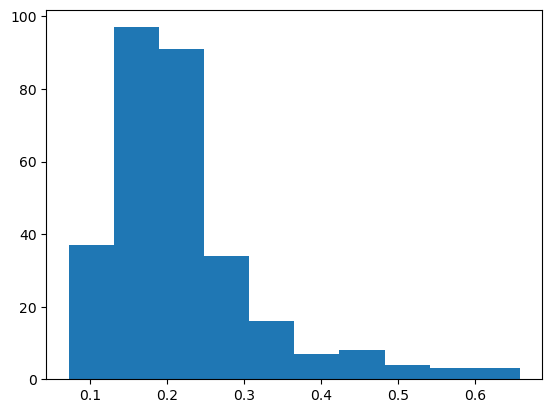

In [8]:
plt.hist(distance_K_df["distance_K"])

In [9]:
combined_df = pd.concat([df, distance_K_df], axis=1, ignore_index=False)

# Define the file path using f-string and expand the home directory
file_path = os.path.expanduser(f'~/project/R_processed_data/estimated_parameters_3.csv')

# Save the combined DataFrame to a CSV file
combined_df.to_csv(file_path, index=False)
combined_df

,sigma_11,sigma_12,sigma_22,sigma_13,sigma_23,sigma_33,alpha_11,alpha_12,alpha_22,alpha_13,...,nu_13,nu_23,nu_33,tau_11,tau_12,tau_22,tau_13,tau_23,tau_33,distance_K
0,1.055559,-0.035930,0.855735,-0.100698,0.072179,0.953431,0.108404,0.029756,0.021449,0.052459,...,1.209181,0.880162,0.944168,0.0,0.0,0.0,0.0,0.0,0.0,0.091821
1,0.969992,0.038814,1.158701,0.087464,0.034416,0.983609,0.002242,0.003171,0.563391,0.003171,...,0.516464,0.024778,0.001887,0.0,0.0,0.0,0.0,0.0,0.0,0.338287
2,1.051836,-0.141381,0.934452,0.113725,0.050191,1.101182,0.027901,0.039387,0.466506,0.018007,...,1.551012,0.242025,0.381977,0.0,0.0,0.0,0.0,0.0,0.0,0.243982
3,0.907243,-0.023080,0.921346,-0.062340,0.032148,1.122307,2.102564,2.614379,4.308961,0.002556,...,0.519179,0.517684,1.030605,0.0,0.0,0.0,0.0,0.0,0.0,0.182571
4,1.151404,0.039286,0.788973,0.024279,-0.002389,1.019615,0.015324,0.003911,0.002812,0.021672,...,0.929280,0.524195,0.005774,0.0,0.0,0.0,0.0,0.0,0.0,0.249350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.129604,-0.019367,0.910461,-0.038204,-0.100787,0.980129,0.000353,0.000499,0.098064,0.000499,...,0.903406,0.488933,0.380965,0.0,0.0,0.0,0.0,0.0,0.0,0.170080
296,0.880579,-0.052441,0.974454,0.051327,-0.057444,1.053308,1889.445203,0.018605,0.013156,1687.609919,...,0.039071,0.957897,0.001997,0.0,0.0,0.0,0.0,0.0,0.0,0.390489
297,1.199618,0.009738,1.154256,-0.051634,-0.166764,1.004124,0.003654,0.005168,3.688400,0.005167,...,0.765350,0.120839,0.189062,0.0,0.0,0.0,0.0,0.0,0.0,0.476645
298,0.941260,-0.065413,0.919731,-0.095455,0.047983,1.051453,0.189910,0.068999,0.050485,0.071024,...,0.724255,0.945113,0.138907,0.0,0.0,0.0,0.0,0.0,0.0,0.095082


# Afterwards, we can load in the python files.
# Boxplot Side-by-Side Comparison follows.

In [10]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import os
# Define the file paths
r_file_path = os.path.expanduser('~/project/R_processed_data/estimated_parameters_3.csv')
# python_file_path = os.path.expanduser('~/project/python_processed_data/33_estimated_parameters.csv')
python_file_path = os.path.expanduser('~/project/python_processed_data/synthetic_estimated_parameters_1.csv')

In [11]:
# Initialize a list to store each DataFrame
df = pd.DataFrame()
df_r = pd.read_csv(r_file_path)
df_r

,sigma_11,sigma_12,sigma_22,sigma_13,sigma_23,sigma_33,alpha_11,alpha_12,alpha_22,alpha_13,...,nu_13,nu_23,nu_33,tau_11,tau_12,tau_22,tau_13,tau_23,tau_33,distance_K
0,1.055559,-0.035930,0.855735,-0.100698,0.072179,0.953431,0.108404,0.029756,0.021449,0.052459,...,1.209181,0.880162,0.944168,0.0,0.0,0.0,0.0,0.0,0.0,0.091821
1,0.969992,0.038814,1.158701,0.087464,0.034416,0.983609,0.002242,0.003171,0.563391,0.003171,...,0.516464,0.024778,0.001887,0.0,0.0,0.0,0.0,0.0,0.0,0.338287
2,1.051836,-0.141381,0.934452,0.113725,0.050191,1.101182,0.027901,0.039387,0.466506,0.018007,...,1.551012,0.242025,0.381977,0.0,0.0,0.0,0.0,0.0,0.0,0.243982
3,0.907243,-0.023080,0.921346,-0.062340,0.032148,1.122307,2.102564,2.614379,4.308961,0.002556,...,0.519179,0.517684,1.030605,0.0,0.0,0.0,0.0,0.0,0.0,0.182571
4,1.151404,0.039286,0.788973,0.024279,-0.002389,1.019615,0.015324,0.003911,0.002812,0.021672,...,0.929280,0.524195,0.005774,0.0,0.0,0.0,0.0,0.0,0.0,0.249350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.129604,-0.019367,0.910461,-0.038204,-0.100787,0.980129,0.000353,0.000499,0.098064,0.000499,...,0.903406,0.488933,0.380965,0.0,0.0,0.0,0.0,0.0,0.0,0.170080
296,0.880579,-0.052441,0.974454,0.051327,-0.057444,1.053308,1889.445203,0.018605,0.013156,1687.609919,...,0.039071,0.957897,0.001997,0.0,0.0,0.0,0.0,0.0,0.0,0.390489
297,1.199618,0.009738,1.154256,-0.051634,-0.166764,1.004124,0.003654,0.005168,3.688400,0.005167,...,0.765350,0.120839,0.189062,0.0,0.0,0.0,0.0,0.0,0.0,0.476645
298,0.941260,-0.065413,0.919731,-0.095455,0.047983,1.051453,0.189910,0.068999,0.050485,0.071024,...,0.724255,0.945113,0.138907,0.0,0.0,0.0,0.0,0.0,0.0,0.095082


In [12]:
df_r["distance_K"]

0      0.091821
1      0.338287
2      0.243982
3      0.182571
4      0.249350
         ...   
295    0.170080
296    0.390489
297    0.476645
298    0.095082
299    0.128989
Name: distance_K, Length: 300, dtype: float64

In [13]:
df_python = pd.read_csv(python_file_path)
df_python

,alpha_matrix_11,nu_matrix_11,sigma_matrix_11,alpha_matrix_12,nu_matrix_12,sigma_matrix_12,alpha_matrix_13,nu_matrix_13,sigma_matrix_13,alpha_matrix_22,nu_matrix_22,sigma_matrix_22,alpha_matrix_23,nu_matrix_23,sigma_matrix_23,alpha_matrix_33,nu_matrix_33,sigma_matrix_33,distance_K
0,2.220446e-16,0.978202,0.799795,0.901110,1.811569,-3.984194e-09,0.902762,1.446475,-7.460089e-09,2.220446e-16,1.020926,1.078313,0.902762,1.467837,-7.409650e-09,7.720880e-02,0.290739,0.998183,0.141330
1,2.660532e-02,1.851239,1.031957,0.900606,3.588310,-1.357585e-32,0.900840,1.821835,-4.054863e-33,3.841639e-02,3.705380,1.148668,0.901053,2.748905,-6.130662e-33,4.814550e-02,0.172430,0.930689,0.130245
2,5.137621e-02,3.765750,1.023739,0.673071,4.152462,-3.417656e-02,0.673566,4.076551,-8.899580e-17,2.589614e-03,2.001024,1.068425,0.672588,3.194188,-2.251978e-17,3.660642e-02,1.849201,1.025074,0.121921
3,8.978010e-02,0.026045,1.105544,0.903194,1.337238,-3.700098e-21,0.903194,1.335722,-3.702820e-21,2.220446e-16,1.024977,0.841949,0.900960,1.835189,-2.929068e-09,2.220446e-16,1.021946,1.033303,0.131266
4,3.584071e-02,3.818583,0.730164,0.900662,3.209863,-7.567937e-09,0.900662,3.231652,-7.729889e-09,2.220446e-16,0.980051,1.092422,0.900305,1.812386,-3.187847e-09,2.220446e-16,1.023629,1.157891,0.151293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.002106e-02,1.802873,0.929553,0.849301,3.212543,-8.863305e-21,0.849200,1.836547,-2.003359e-21,1.852352e-02,3.735264,0.992399,0.849271,2.802743,-1.848097e-09,2.220446e-16,0.983272,1.105883,0.130542
296,8.818116e-03,3.766838,0.915250,1.050573,2.836820,-9.739084e-10,1.050573,2.836401,-9.735056e-10,2.220446e-16,1.017770,1.039529,1.050554,1.461867,-1.404052e-09,2.220446e-16,1.016933,0.970614,0.127988
297,8.393813e-03,1.863673,1.058874,0.909758,2.574672,-6.709272e-10,0.909758,2.574446,-6.708518e-10,2.220446e-16,0.983175,1.132735,0.909738,2.134197,-4.623485e-09,2.220446e-16,0.982724,1.150992,0.139363
298,2.220446e-16,1.016741,0.912971,0.742663,2.569591,-5.300319e-21,0.742353,2.169578,-2.018334e-09,3.036383e-02,1.816805,1.042045,0.742663,2.569610,-5.300409e-21,2.220446e-16,1.016780,0.989203,0.133320


In [14]:
df_python["distance_K"]

0      0.141330
1      0.130245
2      0.121921
3      0.131266
4      0.151293
         ...   
295    0.130542
296    0.127988
297    0.139363
298    0.133320
299    0.126470
Name: distance_K, Length: 300, dtype: float64

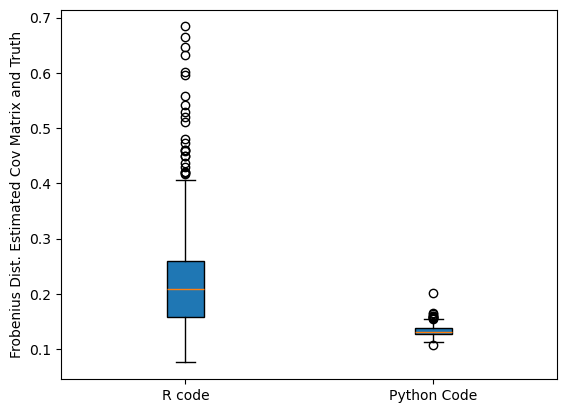

In [17]:
data = [df_r["distance_K"] , df_python["distance_K"]]
plt.boxplot(data, tick_labels = ["R code", "Python Code"], patch_artist=True)
plt.title("")
plt.ylabel("Frobenius Dist. Estimated Cov Matrix and Truth")
plt.show()

In [22]:
ground_truth_df

,alpha_matrix_11,nu_matrix_11,sigma_matrix_11,alpha_matrix_12,nu_matrix_12,sigma_matrix_12,alpha_matrix_13,nu_matrix_13,sigma_matrix_13,alpha_matrix_22,nu_matrix_22,sigma_matrix_22,alpha_matrix_23,nu_matrix_23,sigma_matrix_23,alpha_matrix_33,nu_matrix_33,sigma_matrix_33
0,0.01,1.2,1.0,0.0205,1.093,-0.286,0.0263,1.092,-0.181,0.02,0.6,1.0,0.0282,0.99,0.274,0.03,0.3,1.0


(array([  2.,  65., 137.,  65.,  22.,   7.,   1.,   0.,   0.,   1.]),
 array([0.10717808, 0.11664034, 0.12610259, 0.13556485, 0.14502711,
        0.15448936, 0.16395162, 0.17341387, 0.18287613, 0.19233838,
        0.20180064]),
 <BarContainer object of 10 artists>)

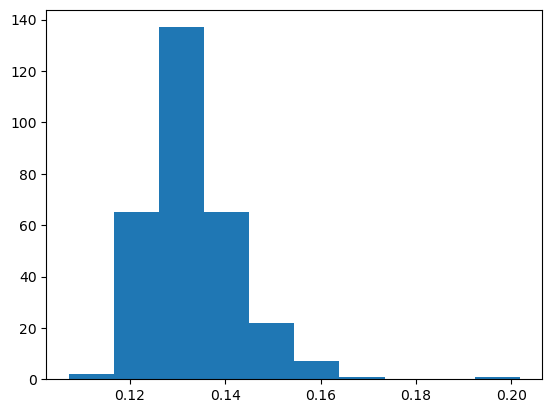

In [23]:
plt.hist(df_python["distance_K"])

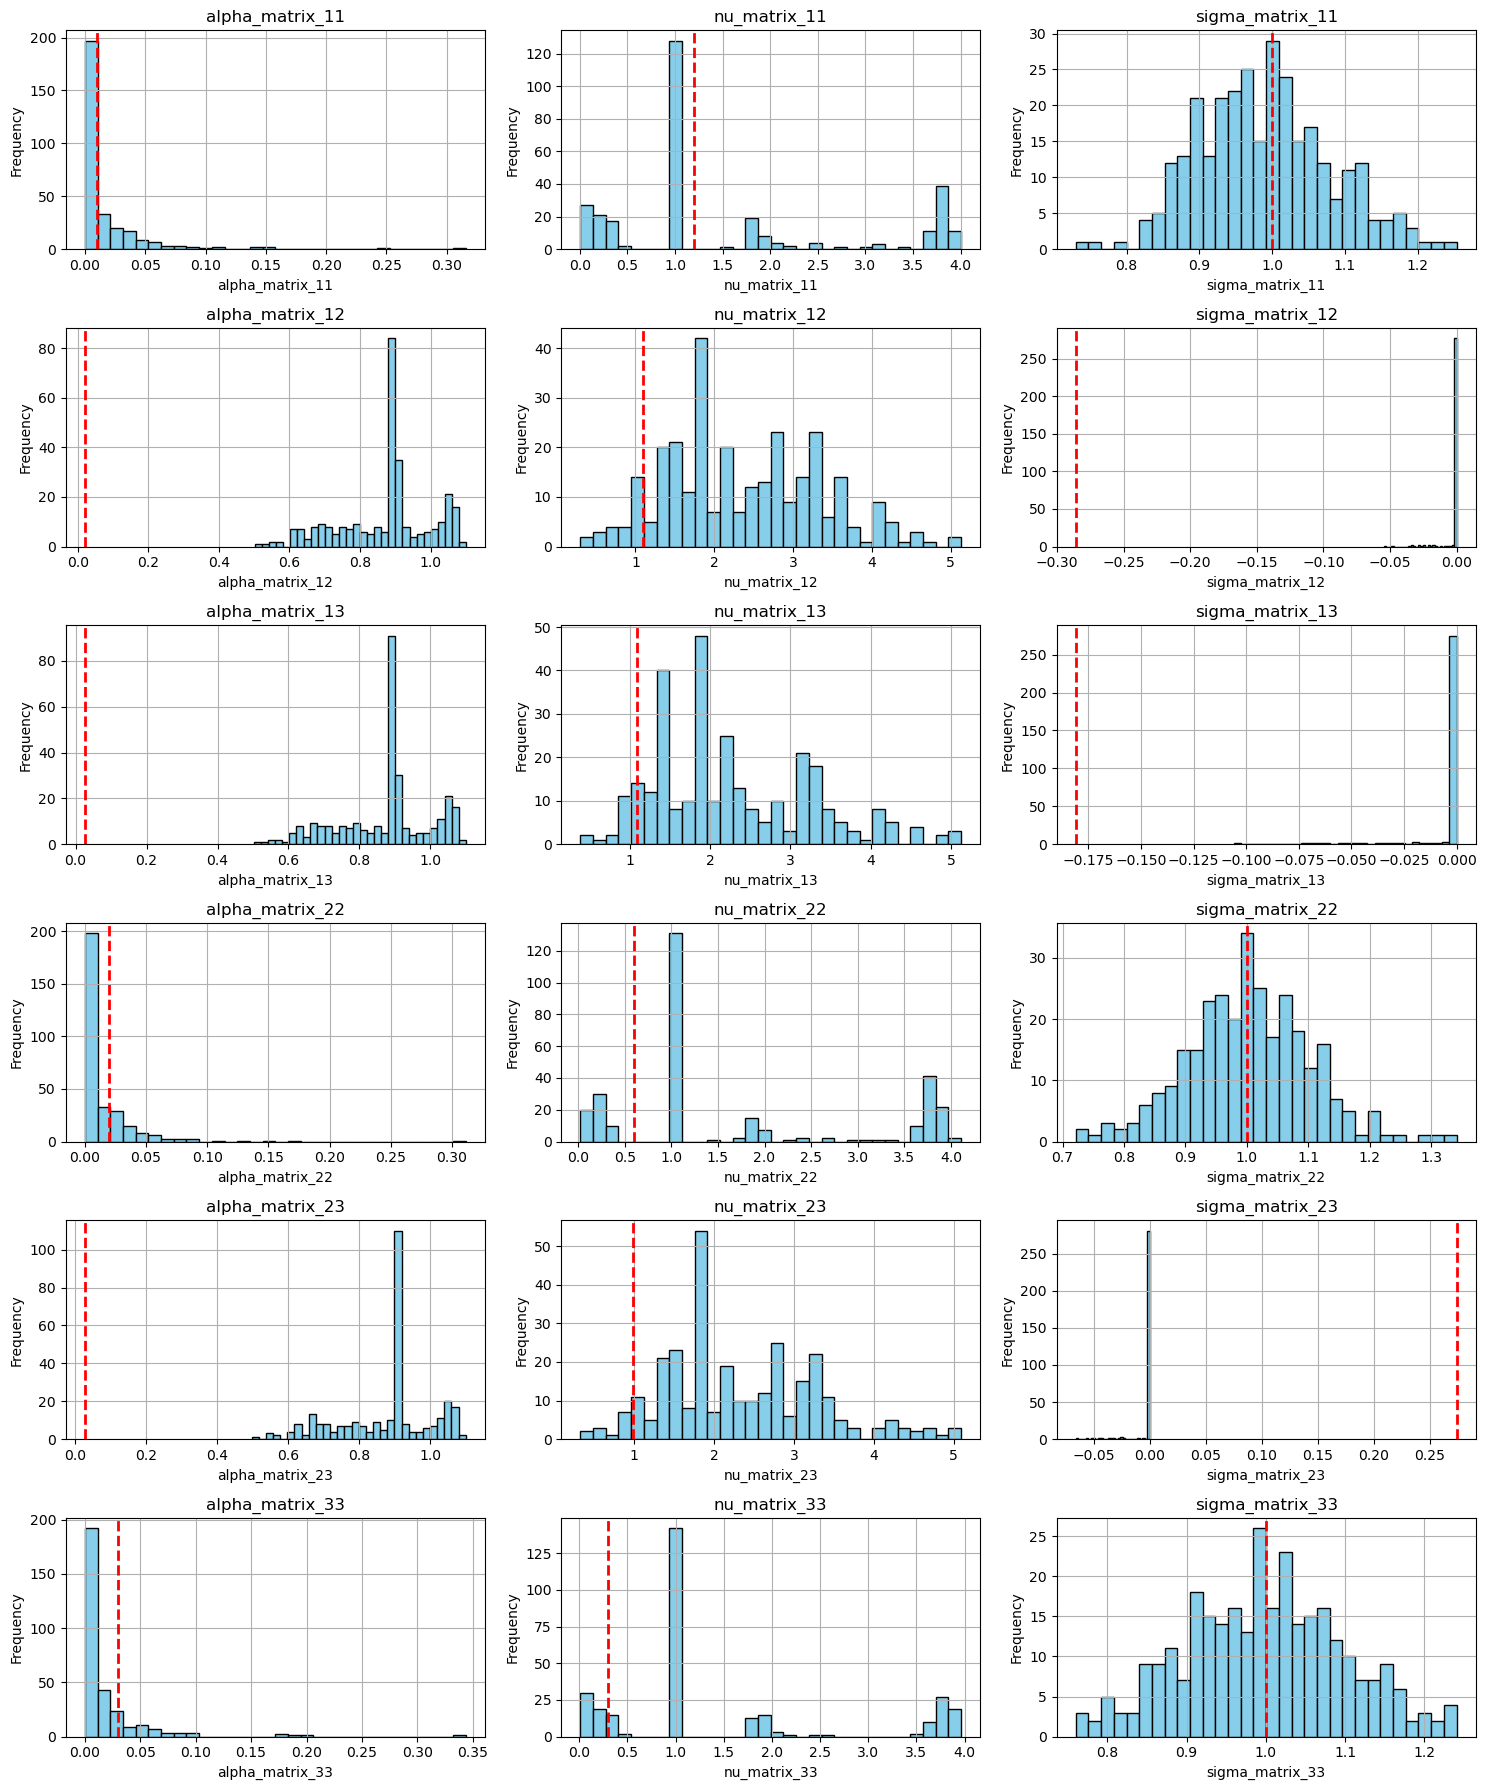

In [28]:
df_to_plot = df_python.drop(columns=["distance_K"])
%run -i epilogue

# 27 Oct 2024 Comparison of $\alpha_1$ estimates.  Remember that ground truth is $0.01$.

In [67]:
# Remove outliers; otherwise the estimates are completely unreasonable.
# Calculate the Interquartile Range (IQR)
Q1 = df_r["alpha_11"].quantile(0.25)
Q3 = df_r["alpha_11"].quantile(0.75)
IQR = Q3 - Q1
# Define the lower and upper bounds for non-outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filter out the outliers
df_r_filtered = df_r[(df_r["alpha_11"] >= lower_bound) & (df_r["alpha_11"] <= upper_bound)]

# Calculate the Interquartile Range (IQR)
Q1 = df_python["alpha_matrix_11"].quantile(0.25)
Q3 = df_python["alpha_matrix_11"].quantile(0.75)
IQR = Q3 - Q1
# Define the lower and upper bounds for non-outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filter out the outliers
df_python_filtered = df_python[(df_python["alpha_matrix_11"] >= lower_bound) & (df_python["alpha_matrix_11"] <= upper_bound)]

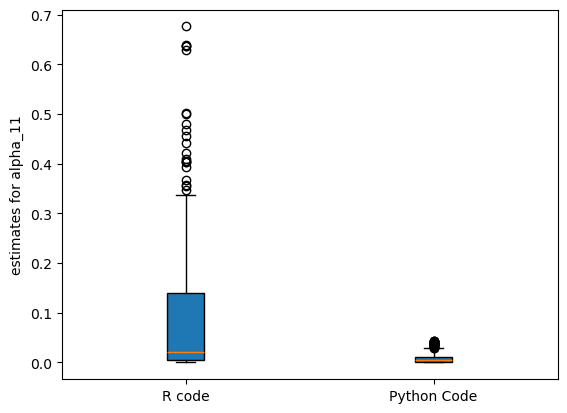

In [68]:
data = [df_r_filtered["alpha_11"] , df_python_filtered["alpha_matrix_11"]]
plt.boxplot(data, labels = ["R code", "Python Code"], patch_artist=True)
plt.title("")
plt.ylabel("estimates for alpha_11")
plt.show()

In [69]:
df_r_filtered["alpha_11"].mean()

0.09905373392892754

In [70]:
df_r_filtered["alpha_11"].std()

0.1457275258748474

In [86]:
df_r["alpha_11"].mean()

4.752968113479128e+18

In [87]:
df_r["alpha_11"].std()

8.232382254301807e+19

In [88]:
df_python_filtered["alpha_matrix_11"].mean()

0.008348625439634851

In [89]:
df_python_filtered["alpha_matrix_11"].std()

0.011506986402892614

In [90]:
df_python["alpha_matrix_11"].mean()

0.01691160653022464

In [91]:
df_python["alpha_matrix_11"].std()

0.0337979558341641